In [30]:
import cv2
import torch
import numpy as np

from pathlib import Path
from ultralytics import YOLO
import torchvision.transforms as transforms
import torchvision.models as models
import torch.nn as nn

In [31]:
VIDEO_PATH = Path(r"C:\Users\klanz\Desktop\MAGISTERKA\video\test2.mp4")

OUTPUT_VIDEO_PATH = Path(r"C:\Users\klanz\Desktop\MAGISTERKA\video\wynik_pipeline2.mp4")

YOLO_MODEL_PATH = Path(r"C:\Users\klanz\Desktop\MAGISTERKA\notebooks\runs\detect\runs\YOLOv8_baseline-2\weights\best.pt")

CNN_MODEL_PATH = Path(r"C:\Users\klanz\Desktop\MAGISTERKA\notebooks\best_chicken_cnn_augument2.pth")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Urządzenie:", DEVICE)

Urządzenie: cuda


In [32]:
yolo_model = YOLO(str(YOLO_MODEL_PATH))

print("YOLO załadowane.")

YOLO załadowane.


In [33]:
cnn_model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

num_features = cnn_model.fc.in_features

cnn_model.fc = nn.Sequential(
    nn.Linear(num_features, 128),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(128, 2)
)

cnn_model.load_state_dict(torch.load(CNN_MODEL_PATH,))

cnn_model = cnn_model.to(DEVICE)

cnn_model.eval()

print("CNN załadowane.")

CNN załadowane.


C:\Users\klanz\AppData\Local\Temp\ipykernel_35352\526583833.py:12: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  cnn_model.load_state_dict(torch.load(CNN_MODEL_PATH,))


In [34]:
cnn_transform = transforms.Compose([

    transforms.ToPILImage(),

    transforms.Resize(
        (224, 224)
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [35]:
def classify_crop(crop):

    if crop is None or crop.size == 0:
        return None, 0.0

    tensor = cnn_transform(crop)

    tensor = tensor.unsqueeze(0)

    tensor = tensor.to(DEVICE)

    with torch.no_grad():

        output = cnn_model(
            tensor
        )

        probabilities = torch.softmax(
            output,
            dim=1
        )

        confidence, prediction = torch.max(
            probabilities,
            dim=1
        )

    predicted_class = int(
        prediction.item()
    )

    confidence = float(
        confidence.item()
    )

    return predicted_class, confidence

In [36]:
def make_door_decision(detections):

    if len(detections) == 0:

        return 0, "ZAMKNIĘTE"

    classes = [
        detection[0]
        for detection in detections
    ]

    if 1 in classes:

        return 0, "ZAMKNIĘTE"

    if len(detections) == 0:
    
            return 0, "ZAMKNIĘTE"
    

    if all(cls == 0 for cls in classes):

        return 1, "OTWARTE"

    return 0, "ZAMKNIĘTE"

In [37]:
cap = cv2.VideoCapture(
    str(VIDEO_PATH)
)

if not cap.isOpened():

    raise RuntimeError(
        f"Nie można otworzyć pliku: {VIDEO_PATH}"
    )

fps = cap.get(
    cv2.CAP_PROP_FPS
)

width = int(
    cap.get(
        cv2.CAP_PROP_FRAME_WIDTH
    )
)

height = int(
    cap.get(
        cv2.CAP_PROP_FRAME_HEIGHT
    )
)

frame_count = int(
    cap.get(
        cv2.CAP_PROP_FRAME_COUNT
    )
)

print("FPS:", fps)
print("Rozdzielczość:", width, "x", height)
print("Liczba klatek:", frame_count)

FPS: 30.0
Rozdzielczość: 1920 x 1080
Liczba klatek: 413


In [38]:
fourcc = cv2.VideoWriter_fourcc(
    *"mp4v"
)

writer = cv2.VideoWriter(
    str(OUTPUT_VIDEO_PATH),
    fourcc,
    fps,
    (width, height)
)

if not writer.isOpened():

    raise RuntimeError(
        "Nie można utworzyć pliku wynikowego."
    )

print(
    "Zapisywanie do:",
    OUTPUT_VIDEO_PATH
)

Zapisywanie do: C:\Users\klanz\Desktop\MAGISTERKA\video\wynik_pipeline2.mp4


In [39]:
frame_number = 0

while True:

    ret, frame = cap.read()

    if not ret:
        break

    frame_number += 1

    # YOLO 
    
    result = yolo_model.predict(
        source=frame,
        conf=0.5,
        device=DEVICE,
        verbose=False
    )[0]


    detections = []


    # CNN dla bounding box 

    if result.boxes is not None:

        for box in result.boxes:

            xyxy = box.xyxy[0].cpu().numpy()

            x1, y1, x2, y2 = xyxy.astype(int)

            x1 = max(0, x1)
            y1 = max(0, y1)

            x2 = min(width, x2)
            y2 = min(height, y2)


            if x2 <= x1 or y2 <= y1:
                continue


            crop = frame[
                y1:y2,
                x1:x2
            ]

            # CNN
            
            predicted_class, cnn_confidence = classify_crop(
                crop
            )


            if predicted_class is None:
                continue


            detections.append(
                (
                    predicted_class,
                    cnn_confidence
                )
            )


            if predicted_class == 0:

                box_color = (0, 255, 0)

                label = (
                    f"KURA "
                    f"{cnn_confidence:.2f}"
                )

            else:

                box_color = (0, 0, 255)

                label = (
                    f"NIE-KURA "
                    f"{cnn_confidence:.2f}"
                )


            # boundingbox
            
            cv2.rectangle( frame, (x1, y1), (x2, y2), box_color, 2)

            cv2.putText(frame, label, (x1, max(y1 - 10, 20)),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, box_color, 2)


    # DECYZJA

    door_state, door_text = make_door_decision(
        detections
    )

    # INFORMACJE O KLATCE

    chicken_count = sum(1 for cls, conf in detections if cls == 0)
    other_count = sum(1 for cls, conf in detections if cls == 1)

    # NAPIS O STANIE DRZWI

    cv2.putText(frame, f"DRZWI: {door_text}", (20, 40),
        cv2.FONT_HERSHEY_SIMPLEX, 1.0, 
        (0, 255, 0) if door_state == 1 else (0, 0, 255), 3)

    # INFORMACJE O OBIEKTACH

    cv2.putText(frame, f"Kury: {chicken_count}", (20, 80),
        cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2
    )

    cv2.putText(frame, f"Nie-kury: {other_count}", (20, 110),
        cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 255), 2
    )

    # ZAPIS KLATKI

    writer.write(frame)

    # POSTĘP

    if frame_number % 100 == 0:

        print(
            f"Przetworzono {frame_number}/{frame_count} klatek"
        )

Przetworzono 100/413 klatek
Przetworzono 200/413 klatek
Przetworzono 300/413 klatek
Przetworzono 400/413 klatek


In [40]:
cap.release()
writer.release()

print()
print("PRZETWARZANIE ZAKOŃCZONE")
print()
print("Wynik zapisano tutaj:")
print(OUTPUT_VIDEO_PATH)


PRZETWARZANIE ZAKOŃCZONE

Wynik zapisano tutaj:
C:\Users\klanz\Desktop\MAGISTERKA\video\wynik_pipeline2.mp4


In [41]:
YOLO_ONLY_OUTPUT_PATH = Path(
    r"C:\Users\klanz\Desktop\MAGISTERKA\video\wynik_yolo2.mp4"
)

In [42]:
cap = cv2.VideoCapture(
    str(VIDEO_PATH)
)

if not cap.isOpened():
    raise RuntimeError(
        f"Nie można otworzyć pliku: {VIDEO_PATH}"
    )

fps = cap.get(cv2.CAP_PROP_FPS)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

fourcc = cv2.VideoWriter_fourcc(*"mp4v")

writer = cv2.VideoWriter(
    str(YOLO_ONLY_OUTPUT_PATH),
    fourcc,
    fps,
    (width, height)
)

if not writer.isOpened():
    raise RuntimeError(
        "Nie można utworzyć pliku wynikowego."
    )

print("Rozpoczynam przetwarzanie YOLO...")

Rozpoczynam przetwarzanie YOLO...


In [43]:
frame_number = 0

while True:
    ret, frame = cap.read()
    if not ret:
        break

    frame_number += 1

    # YOLO – detekcja
    result = yolo_model.predict(
        source=frame,
        conf=0.5,
        device=DEVICE,
        verbose=False
    )[0]

    detections = []   

    # ANALIZA BOUNDING BOXÓW
    if result.boxes is not None:
        for box in result.boxes:
            cls = int(box.cls[0].item())
            confidence = float(box.conf[0].item())

            xyxy = box.xyxy[0].cpu().numpy()
            x1, y1, x2, y2 = xyxy.astype(int)
            x1 = max(0, x1)
            y1 = max(0, y1)
            x2 = min(width, x2)
            y2 = min(height, y2)

            detections.append((cls, confidence))

            if cls == 0:          
                box_color = (0, 255, 0)
                label = f"KURA {confidence:.2f}"
            elif cls == 1:        
                box_color = (0, 0, 255)
                label = f"NIE-KURA {confidence:.2f}"
            else:
                continue          
            
            cv2.rectangle(frame, (x1, y1), (x2, y2), box_color, 2)
            cv2.putText(frame, label, (x1, max(y1 - 10, 20)),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.6, box_color, 2)

    # DECYZJA
    door_state, door_text = make_door_decision(detections)

    # INFORMACJA O KLATCE
    chicken_count = sum(1 for cls, _ in detections if cls == 0)
    other_count   = sum(1 for cls, _ in detections if cls == 1)

    # NAPIS O STANIE DRZWI
    cv2.putText(frame, f"DRZWI: {door_text}", (20, 40),
                cv2.FONT_HERSHEY_SIMPLEX, 1.0,
                (0, 255, 0) if door_state == 1 else (0, 0, 255), 3)

    # INFORMACJE O OBIEKTACH
    cv2.putText(frame, f"Kury: {chicken_count}", (20, 80),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)
    cv2.putText(frame, f"Nie-kury: {other_count}", (20, 110),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 255), 2)

    # ZAPIS KLATKI
    writer.write(frame)

    #POSTĘP
    if frame_number % 100 == 0:
        print(f"Przetworzono {frame_number}/{frame_count} klatek")

Przetworzono 100/413 klatek
Przetworzono 200/413 klatek
Przetworzono 300/413 klatek
Przetworzono 400/413 klatek


In [44]:
cap.release()
writer.release()

print()
print("YOLO - PRZETWARZANIE ZAKOŃCZONE")
print()
print("Wynik zapisano:")
print(YOLO_ONLY_OUTPUT_PATH)


YOLO - PRZETWARZANIE ZAKOŃCZONE

Wynik zapisano:
C:\Users\klanz\Desktop\MAGISTERKA\video\wynik_yolo2.mp4


In [45]:
import csv
from collections import defaultdict

In [46]:
def save_evaluation_csv(
    frame_results,
    output_prefix,
    fps
):
    
    output_prefix = Path(output_prefix)
    
    # CSV DLA KAŻDEJ KLATKI
   
    frame_csv = output_prefix.with_name(
        output_prefix.stem + "_klatki2.csv"
    )
    
    with open(
        frame_csv,
        "w",
        newline="",
        encoding="utf-8-sig"
    ) as f:
        
        writer = csv.writer(f)
        
        writer.writerow([
            "frame",
            "czas_s",
            "kury",
            "nie_kury",
            "drzwi"
        ])
        
        for row in frame_results:
            
            writer.writerow([
                row["frame"],
                f'{row["time"]:.3f}',
                row["chickens"],
                row["other"],
                row["door"]
            ])
    
    
    # SEKUNDY

    seconds = defaultdict(list)
    
    for row in frame_results:
        
        second = int(row["time"])
        
        seconds[second].append(row)
    
    
    seconds_csv = output_prefix.with_name(
        output_prefix.stem + "_sekundy2.csv"
    )
    
    with open(
        seconds_csv,
        "w",
        newline="",
        encoding="utf-8-sig"
    ) as f:
        
        writer = csv.writer(f)
        
        writer.writerow([
            "sekunda",
            "liczba_klatek",
            "suma_wykrytych_kur",
            "suma_wykrytych_nie_kur",
            "klatki_otwarte",
            "klatki_zamkniete"
        ])
        
        for second in sorted(seconds):
            
            rows = seconds[second]
            
            chickens = sum(
                row["chickens"]
                for row in rows
            )
            
            other = sum(
                row["other"]
                for row in rows
            )
            
            open_frames = sum(
                row["door"] == 1
                for row in rows
            )
            
            closed_frames = sum(
                row["door"] == 0
                for row in rows
            )
            
            writer.writerow([
                second,
                len(rows),
                chickens,
                other,
                open_frames,
                closed_frames
            ])
    
    
    print("Zapisano:")
    print(frame_csv)
    print(seconds_csv)

In [47]:
yolo_frame_results = []

cap = cv2.VideoCapture(
    str(VIDEO_PATH)
)

if not cap.isOpened():
    raise RuntimeError(
        f"Nie można otworzyć: {VIDEO_PATH}"
    )

fps = cap.get(cv2.CAP_PROP_FPS)

frame_number = 0

while True:

    ret, frame = cap.read()

    if not ret:
        break

    frame_number += 1

    # CZAS KLATKI
    
    time_seconds = (
        frame_number - 1
    ) / fps


    # YOLO
    
    result = yolo_model.predict(
        source=frame,
        conf=0.5,
        device=DEVICE,
        verbose=False
    )[0]


    chicken_count = 0
    other_count = 0


    # DETEKCJE
    
    if result.boxes is not None:

        for box in result.boxes:

            cls = int(
                box.cls[0].item()
            )

            if cls == 0:

                chicken_count += 1

            elif cls == 1:

                other_count += 1


    # DECYZJA
    
    if other_count > 0:

        door_state = 0

    elif chicken_count > 0:

        door_state = 1

    else:

        door_state = 0


    # ZAPIS
    
    yolo_frame_results.append({
        "frame": frame_number,
        "time": time_seconds,
        "chickens": chicken_count,
        "other": other_count,
        "door": door_state
    })


cap.release()

print(
    f"Przetworzono {frame_number} klatek."
)

Przetworzono 413 klatek.


In [48]:
YOLO_CSV_PREFIX = Path("C:\\Users\\klanz\\Desktop\\MAGISTERKA\\notebooks\\wyniki\\yolo")

YOLO_CSV_PREFIX.parent.mkdir(
    parents=True,
    exist_ok=True
)

save_evaluation_csv(
    yolo_frame_results,
    YOLO_CSV_PREFIX,
    fps
)

Zapisano:
C:\Users\klanz\Desktop\MAGISTERKA\notebooks\wyniki\yolo_klatki2.csv
C:\Users\klanz\Desktop\MAGISTERKA\notebooks\wyniki\yolo_sekundy2.csv


In [49]:
pipeline_frame_results = []

cap = cv2.VideoCapture(
    str(VIDEO_PATH)
)

if not cap.isOpened():
    raise RuntimeError(
        f"Nie można otworzyć: {VIDEO_PATH}"
    )

fps = cap.get(cv2.CAP_PROP_FPS)

frame_number = 0

while True:

    ret, frame = cap.read()

    if not ret:
        break

    frame_number += 1

    time_seconds = (
        frame_number - 1
    ) / fps


    # YOLO
    
    result = yolo_model.predict(
        source=frame,
        conf=0.5,
        device=DEVICE,
        verbose=False
    )[0]


    chicken_count = 0
    other_count = 0


    # KAŻDY BOUNDING BOX → CNN

    if result.boxes is not None:

        for box in result.boxes:

            xyxy = (
                box.xyxy[0]
                .cpu()
                .numpy()
            )

            x1, y1, x2, y2 = (
                xyxy.astype(int)
            )

            x1 = max(0, x1)
            y1 = max(0, y1)

            x2 = min(
                frame.shape[1],
                x2
            )

            y2 = min(
                frame.shape[0],
                y2
            )


            if x2 <= x1 or y2 <= y1:
                continue


            crop = frame[
                y1:y2,
                x1:x2
            ]

            # CNN
            
            predicted_class, cnn_confidence = (
                classify_crop(crop)
            )


            if predicted_class is None:
                continue

            # ZLICZANIE
            
            if predicted_class == 0:

                chicken_count += 1

            elif predicted_class == 1:

                other_count += 1

    # DECYZJA SYSTEMU
    
    if other_count > 0:

        door_state = 0

    elif chicken_count > 0:

        door_state = 1

    else:

        door_state = 0


    # ZAPIS KLATKI
    
    pipeline_frame_results.append({
        "frame": frame_number,
        "time": time_seconds,
        "chickens": chicken_count,
        "other": other_count,
        "door": door_state
    })


cap.release()

print(
    f"Przetworzono {frame_number} klatek."
)

Przetworzono 413 klatek.


In [50]:
PIPELINE_CSV_PREFIX = Path(
    r"C:\Users\klanz\Desktop\MAGISTERKA\notebooks\wyniki\pipeline"
)

PIPELINE_CSV_PREFIX.parent.mkdir(
    parents=True,
    exist_ok=True
)

save_evaluation_csv(
    pipeline_frame_results,
    PIPELINE_CSV_PREFIX,
    fps
)

Zapisano:
C:\Users\klanz\Desktop\MAGISTERKA\notebooks\wyniki\pipeline_klatki2.csv
C:\Users\klanz\Desktop\MAGISTERKA\notebooks\wyniki\pipeline_sekundy2.csv


In [51]:
#%pip install csvtex


In [52]:
from csvtex import create_latex_table

sciezka_csv = "wyniki\\yolo_sekundy2.csv"

kod_latex = create_latex_table(sciezka_csv, caption="Moja Tabela", label="tab:dane")
print(kod_latex)


\begin{table*}[htb]
    \centering
    \begin{tabular}{@{}cccccc@{}}
        \toprule
        sekunda & liczba\_klatek & suma\_wykrytych\_kur & suma\_wykrytych\_nie\_kur & klatki\_otwarte & klatki\_zamkniete \\
                \midrule
        0 & 30 & 131 & 0 & 30 & 0 \\
        1 & 30 & 76 & 0 & 28 & 2 \\
        2 & 30 & 41 & 1 & 19 & 11 \\
        3 & 30 & 24 & 3 & 14 & 16 \\
        4 & 30 & 31 & 5 & 18 & 12 \\
        5 & 30 & 34 & 0 & 20 & 10 \\
        6 & 30 & 12 & 0 & 10 & 20 \\
        7 & 30 & 17 & 27 & 5 & 25 \\
        8 & 30 & 8 & 12 & 6 & 24 \\
        9 & 30 & 39 & 5 & 18 & 12 \\
        10 & 30 & 12 & 37 & 3 & 27 \\
        11 & 30 & 2 & 28 & 0 & 30 \\
        12 & 30 & 7 & 13 & 3 & 27 \\
        13 & 23 & 34 & 15 & 8 & 15 \\
        \bottomrule
    \end{tabular}

    \caption{\footnotesize Moja Tabela}

    \label{tab:dane}
\end{table*}


In [70]:
#%pip -m install plotly
import pandas as pd
import plotly.graph_objects as go
from pathlib import Path


CSV_PATH = Path(
    r"C:\Users\klanz\Desktop\MAGISTERKA\notebooks\wyniki\yolo_sekundy2.csv"
)

df = pd.read_csv(CSV_PATH)

print(df.head())

   sekunda  liczba_klatek  suma_wykrytych_kur  suma_wykrytych_nie_kur  \
0        0             30                 131                       0   
1        1             30                  76                       0   
2        2             30                  41                       1   
3        3             30                  24                       3   
4        4             30                  31                       5   

   klatki_otwarte  klatki_zamkniete  
0              30                 0  
1              28                 2  
2              19                11  
3              14                16  
4              18                12  


In [71]:
df["decyzja"] = df.apply(
    lambda row:
        "OTWARTE"
        if row["klatki_otwarte"] > row["klatki_zamkniete"]
        else "ZAMKNIĘTE",
    axis=1
)

print(
    df[
        [
            "sekunda",
            "suma_wykrytych_kur",
            "suma_wykrytych_nie_kur",
            "klatki_otwarte",
            "klatki_zamkniete",
            "decyzja"
        ]
    ]
)

    sekunda  suma_wykrytych_kur  suma_wykrytych_nie_kur  klatki_otwarte  \
0         0                 131                       0              30   
1         1                  76                       0              28   
2         2                  41                       1              19   
3         3                  24                       3              14   
4         4                  31                       5              18   
5         5                  34                       0              20   
6         6                  12                       0              10   
7         7                  17                      27               5   
8         8                   8                      12               6   
9         9                  39                       5              18   
10       10                  12                      37               3   
11       11                   2                      28               0   
12       12              

In [72]:
#%pip install nbformat

In [73]:
fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=df["sekunda"],
        y=df["suma_wykrytych_kur"],
        mode="lines+markers",
        name="Wykryte kury",
        line=dict(color="blue"),
        marker=dict(color="blue"),
        hovertemplate=
            "Sekunda: %{x}<br>" +
            "Kury: %{y}<extra></extra>"
    )
)

fig.add_trace(
    go.Scatter(
        x=df["sekunda"],
        y=df["suma_wykrytych_nie_kur"],
        mode="lines+markers",
        name="Wykryte nie-kury",
        line=dict(color="orange"),
        marker=dict(color="orange"),
        hovertemplate=
            "Sekunda: %{x}<br>" +
            "Nie-kury: %{y}<extra></extra>"
    )
)


fig.add_trace(
    go.Scatter(
        x=df["sekunda"],
        y=df["klatki_otwarte"],
        mode="lines+markers",
        name="Klatki — drzwi otwarte",
        line=dict(color="green"),
        marker=dict(color="green"),
        yaxis="y2",
        hovertemplate=
            "Sekunda: %{x}<br>" +
            "Otwarte: %{y} klatek<extra></extra>"
    )
)


fig.add_trace(
    go.Scatter(
        x=df["sekunda"],
        y=df["klatki_zamkniete"],
        mode="lines+markers",
        name="Klatki — drzwi zamknięte",
        line=dict(color="red"),
        marker=dict(color="red"),
        yaxis="y2",
        hovertemplate=
            "Sekunda: %{x}<br>" +
            "Zamknięte: %{y} klatek<extra></extra>"
    )
)

fig.update_layout(

    title="Wykrycia obiektów i decyzja systemu w czasie",

    xaxis=dict(
        title="Czas [s]",
        dtick=1
    ),

    yaxis=dict(
        title="Liczba wykrytych obiektów",
        rangemode="tozero"
    ),

    yaxis2=dict(
        title="Liczba klatek",
        overlaying="y",
        side="right",
        rangemode="tozero",
        range=[
            0,
            df["liczba_klatek"].max() + 2
        ]
    ),

    hovermode="x unified",

    template="plotly_white",

    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=1.02,
        xanchor="center",
        x=0.5
    ),

    height=650
)


fig.show()

In [74]:
import pandas as pd
import plotly.graph_objects as go
from pathlib import Path


CSV_PATH2 = Path(
    r"C:\Users\klanz\Desktop\MAGISTERKA\notebooks\wyniki\yolo_klatki2.csv"
)

df = pd.read_csv(CSV_PATH2)

print(f"Liczba klatek: {len(df)}")
print(f"Czas nagrania: {df['czas_s'].max():.2f} s")

df.head()

Liczba klatek: 413
Czas nagrania: 13.73 s


,frame,czas_s,kury,nie_kury,drzwi
0,1,0.000,3,0,1
1,2,0.033,4,0,1
2,3,0.067,4,0,1
3,4,0.100,4,0,1
4,5,0.133,4,0,1


In [75]:
WINDOW_SIZE = 10
OPEN_THRESHOLD = 5


df["otwarcia_ostatnie_10"] = (
    df["drzwi"]
    .rolling(
        window=WINDOW_SIZE,
        min_periods=WINDOW_SIZE
    )
    .sum()
)


df["decyzja_10"] = 0


valid_window = df["otwarcia_ostatnie_10"].notna()

df.loc[valid_window, "decyzja_10"] = (
    df.loc[valid_window, "otwarcia_ostatnie_10"] >= OPEN_THRESHOLD
).astype(int)


print(
    df[
        [
            "frame",
            "czas_s",
            "drzwi",
            "otwarcia_ostatnie_10",
            "decyzja_10"
        ]
    ].head(30)
)

    frame  czas_s  drzwi  otwarcia_ostatnie_10  decyzja_10
0       1   0.000      1                   NaN           0
1       2   0.033      1                   NaN           0
2       3   0.067      1                   NaN           0
3       4   0.100      1                   NaN           0
4       5   0.133      1                   NaN           0
5       6   0.167      1                   NaN           0
6       7   0.200      1                   NaN           0
7       8   0.233      1                   NaN           0
8       9   0.267      1                   NaN           0
9      10   0.300      1                  10.0           1
10     11   0.333      1                  10.0           1
11     12   0.367      1                  10.0           1
12     13   0.400      1                  10.0           1
13     14   0.433      1                  10.0           1
14     15   0.467      1                  10.0           1
15     16   0.500      1                  10.0          

In [76]:
fig = go.Figure()


fig.add_trace(
    go.Scatter(
        x=df["czas_s"],
        y=df["otwarcia_ostatnie_10"],
        mode="lines+markers",
        name="Otwarcia w ostatnich 10 klatkach",
        line=dict(width=2),
        marker=dict(size=4),
        hovertemplate=
            "Czas: %{x:.3f} s<br>" +
            "Otwarcia: %{y}/10<extra></extra>"
    )
)


fig.add_hline(
    y=5,
    line_dash="dash",
    line_width=2,
    annotation_text="Próg otwarcia: 5/10",
    annotation_position="top left"
)

fig.update_layout(

    title="Decyzja systemu na podstawie ostatnich 10 klatek",

    xaxis=dict(
        title="Czas [s]"
    ),

    yaxis=dict(
        title="Liczba decyzji „otwórz” w ostatnich 10 klatkach",
        range=[0, 10.5],
        dtick=1
    ),

    template="plotly_white",

    hovermode="x unified",

    height=600
)


fig.show()

In [57]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path


CSV_PATH = Path(
    r"C:\Users\klanz\Desktop\MAGISTERKA\notebooks\wyniki\pipeline_klatki2.csv"
)

df = pd.read_csv(CSV_PATH)

print(df.head(20))
print()
print(f"Liczba klatek: {len(df)}")
print(f"Czas nagrania: {df['czas_s'].max():.2f} s")

    frame  czas_s  kury  nie_kury  drzwi
0       1   0.000     3         0      1
1       2   0.033     3         1      0
2       3   0.067     3         1      0
3       4   0.100     3         1      0
4       5   0.133     3         1      0
5       6   0.167     3         1      0
6       7   0.200     4         0      1
7       8   0.233     4         0      1
8       9   0.267     4         0      1
9      10   0.300     4         0      1
10     11   0.333     6         0      1
11     12   0.367     5         1      0
12     13   0.400     5         1      0
13     14   0.433     4         0      1
14     15   0.467     5         0      1
15     16   0.500     5         0      1
16     17   0.533     5         0      1
17     18   0.567     5         0      1
18     19   0.600     5         0      1
19     20   0.633     5         0      1

Liczba klatek: 413
Czas nagrania: 13.73 s


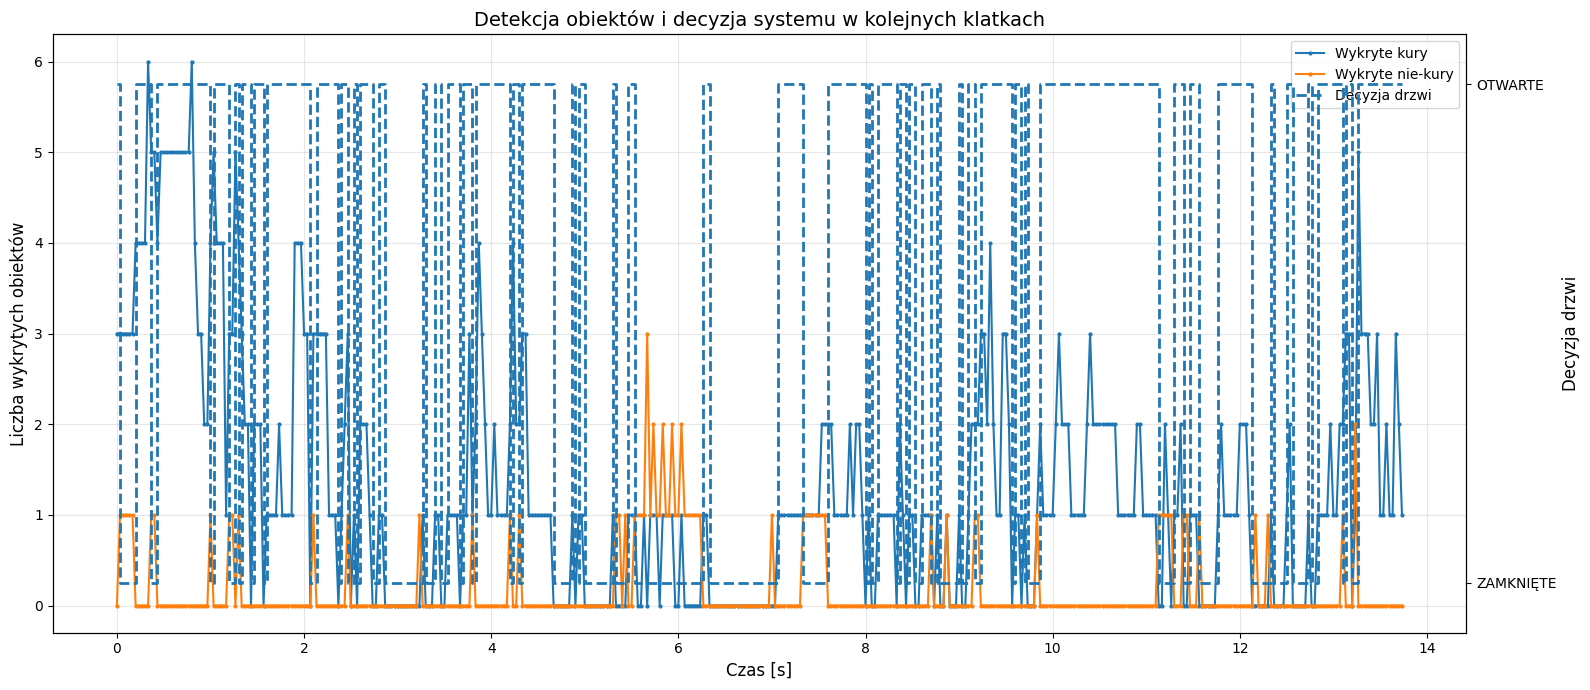

In [ ]:
fig, ax1 = plt.subplots(figsize=(16, 7))


ax1.plot(
    df["czas_s"],
    df["kury"],
    label="Wykryte kury",
    linewidth=1.5,
    marker="o",
    markersize=2
)


ax1.plot(
    df["czas_s"],
    df["nie_kury"],
    label="Wykryte nie-kury",
    linewidth=1.5,
    marker="o",
    markersize=2
)


ax1.set_xlabel(
    "Czas [s]",
    fontsize=12
)

ax1.set_ylabel(
    "Liczba wykrytych obiektów",
    fontsize=12
)

ax1.set_title(
    "Detekcja obiektów i decyzja systemu w kolejnych klatkach",
    fontsize=14
)

ax1.grid(
    True,
    alpha=0.3
)



ax2 = ax1.twinx()

ax2.step(
    df["czas_s"],
    df["drzwi"],
    where="post",
    linewidth=2,
    linestyle="--",
    label="Decyzja drzwi"
)

ax2.set_ylabel(
    "Decyzja drzwi",
    fontsize=12
)

ax2.set_yticks(
    [0, 1]
)

ax2.set_yticklabels(
    ["ZAMKNIĘTE", "OTWARTE"]
)

ax2.set_ylim(
    -0.1,
    1.1
)


lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="upper right"
)


plt.tight_layout()
plt.show()